**lstm**

**First baseline run**

pmdarima not available; falling back to a small manual SARIMAX grid. Reason: No module named 'pmdarima'

=== ARIMA vs LSTM on Stock Prices ===

[Step 1] Downloading data...
                close
Date                 
2022-01-03  33.470001
2022-01-04  31.580000
2022-01-05  29.879999
2022-01-06  29.309999
2022-01-07  29.299999 
...
             close
Date             
2025-10-27   7.04
2025-10-28   7.09
2025-10-29   7.14
2025-10-30   7.01
2025-10-31   7.25
Shape: (962, 1)


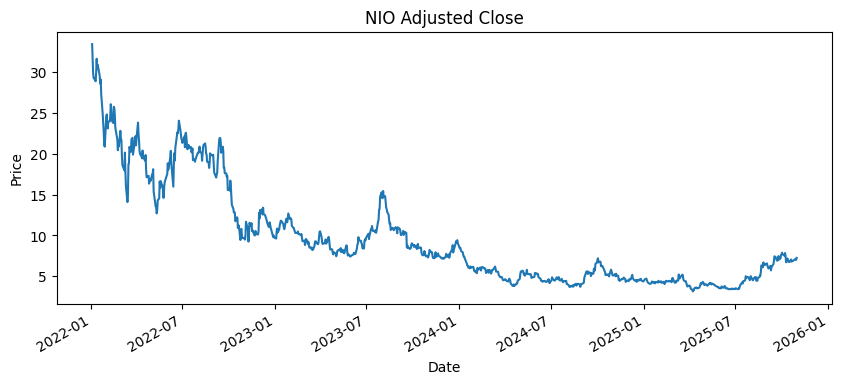


[Step 2] Train–test split...
Train: 2022-01-03 00:00:00 → 2025-05-12 00:00:00 | n= 842
Test : 2025-05-13 00:00:00 → 2025-10-31 00:00:00 | n= 120

[Step 3] Baseline models...
           RMSE       MAE  sMAPE (%)  DirAcc (%)
Naive  1.825926  1.431750  27.612956    1.680672
MA(5)  0.332928  0.234017   4.386179   44.537815


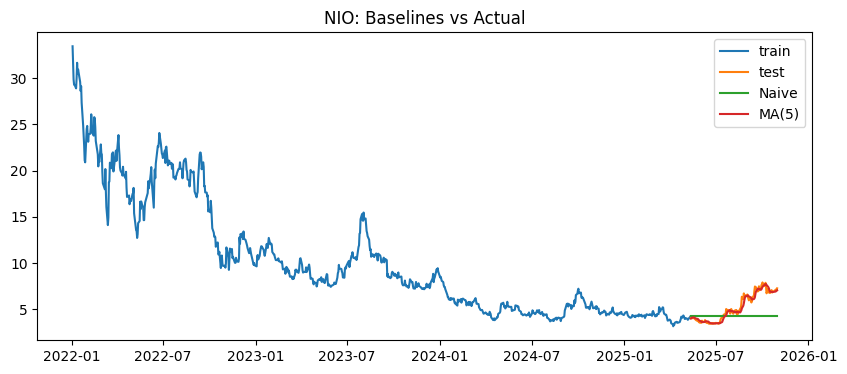


[Step 4] ARIMA (walk-forward) on log price...


d:\projects\personal\ai-playground\aip\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\projects\personal\ai-playground\aip\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\projects\personal\ai-playground\aip\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\projects\personal\ai-playground\aip\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so wil

RMSE           0.236903
MAE            0.171518
sMAPE (%)      3.139184
DirAcc (%)    43.697479
Name: SARIMAX(1, 1, 0), dtype: float64


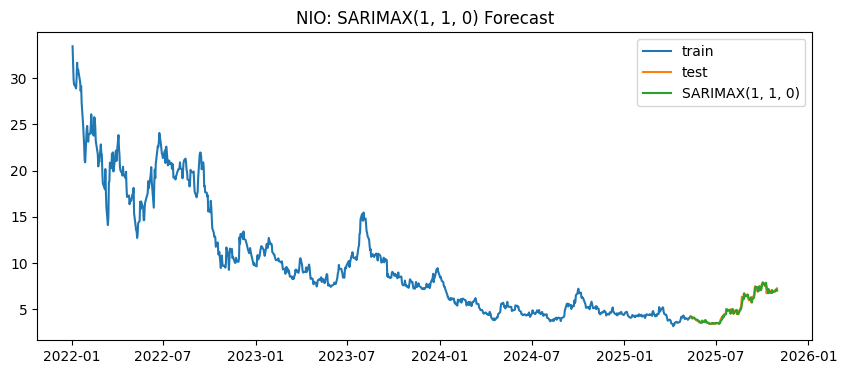


[Step 5] LSTM (windowed next-day price)...
RMSE           0.255446
MAE            0.193437
sMAPE (%)      3.703172
DirAcc (%)    48.739496
Name: LSTM, dtype: float64


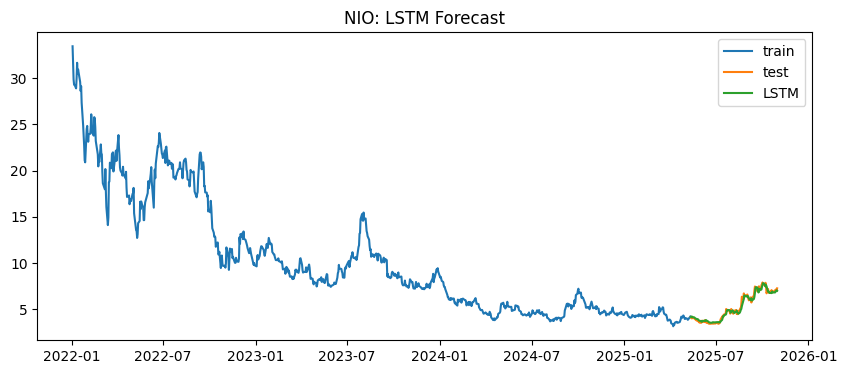


[Step 6] Comparison summary:
                      RMSE       MAE  sMAPE (%)  DirAcc (%)
SARIMAX(1, 1, 0)  0.236903  0.171518   3.139184   43.697479
LSTM              0.255446  0.193437   3.703172   48.739496
MA(5)             0.332928  0.234017   4.386179   44.537815
Naive             1.825926  1.431750  27.612956    1.680672


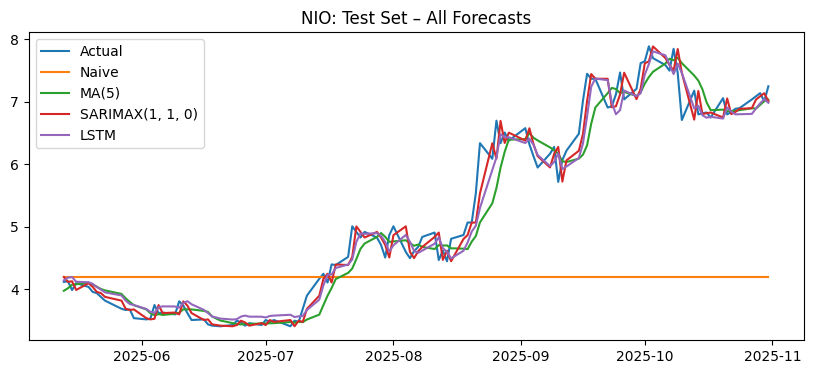


[Step 7] Short analysis (write-up prompts):
1) Which model won on RMSE? Did it also win on sMAPE and Directional Accuracy?
2) Where do models deviate most from actual?
3) Did ARIMA’s transform (log + differences) help vs LSTM’s raw-price approach?
4) Try one concrete next step to improve a model and compare results 



In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
import math
from math import sqrt
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import yfinance as yf

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Try pmdarima for auto_arima; fall back to manual SARIMAX grid if unavailable
HAVE_PM = True
try:
    import pmdarima as pm
except Exception as e:
    HAVE_PM = False
    print("pmdarima not available; falling back to a small manual SARIMAX grid. Reason:", e)

# Try TensorFlow (tf.keras)
try:
    import tensorflow as tf
    from tensorflow import keras
except Exception as e:
    raise RuntimeError("TensorFlow not available. Install tensorflow (or tensorflow-macos on Apple Silicon).") from e


# ---------------------------
# Utility metrics & helpers
# ---------------------------

def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    if len(y_true) < 2 or len(y_pred) < 2:
        return np.nan
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    m = min(len(true_dir), len(pred_dir))
    return np.mean(true_dir[:m] == pred_dir[:m]) * 100

def eval_series(y_true, y_pred):
    # Align indexes to be safe (for pandas Series)
    if isinstance(y_true, (pd.Series, pd.DataFrame)) and isinstance(y_pred, (pd.Series, pd.DataFrame)):
        y_true, y_pred = y_true.squeeze().align(pd.Series(y_pred).squeeze(), join='inner')
    else:
        y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE" : mean_absolute_error(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
        "DirAcc (%)": directional_accuracy(y_true, y_pred)
    }

# ---------------------------
# Data loading
# ---------------------------

# DROP-IN REPLACEMENT for your load_prices() to fix "['Adj Close'] not in index" errors
# Handles: MultiIndex columns (yfinance), missing 'Adj Close' (falls back to 'Close'),
# auto-adjusted downloads, and ensures a single 'close' column with a DatetimeIndex.

import pandas as pd
import yfinance as yf

# --- REPLACE your existing load_prices() with this more robust version ---

import pandas as pd
import yfinance as yf

def load_prices(ticker: str, start: str = "2015-01-01", end: str | None = None) -> pd.DataFrame:
    """
    Robustly fetch daily prices from Yahoo Finance and return a DataFrame with one column:
      - 'close' = adjusted close if available, else close
    Handles: MultiIndex columns, single-column frames like ['TSLA'], auto-adjust cases.
    """
    def _pick_close(df: pd.DataFrame) -> pd.Series:
        # If MultiIndex (typical: top=ticker, bottom=OHLCV)
        if isinstance(df.columns, pd.MultiIndex):
            top = [str(x).upper() for x in df.columns.get_level_values(0)]
            bot = [str(x).lower() for x in df.columns.get_level_values(1)]
            # try to match the requested ticker block if present
            if ticker.upper() in top:
                block = df.xs(ticker.upper(), axis=1, level=0, drop_level=False)
            else:
                # fallback to first block
                first = df.columns.get_level_values(0).unique()[0]
                block = df.xs(first, axis=1, level=0, drop_level=False)
            # now pick column within the block
            cols_lower = {c.lower(): c for c in block.columns.get_level_values(-1)}
            if 'adj close' in cols_lower:
                return block.xs(cols_lower['adj close'], axis=1, level=-1, drop_level=False).iloc[:, 0]
            if 'close' in cols_lower:
                return block.xs(cols_lower['close'], axis=1, level=-1, drop_level=False).iloc[:, 0]
            # last resort: if block has exactly one column, use it
            if block.shape[1] == 1:
                return block.iloc[:, 0]
            raise ValueError(f"No Close/Adj Close under MultiIndex. Bottom-level columns: {sorted(set(bot))}")

        # Single-level columns
        cols_lower = {str(c).lower(): c for c in df.columns}
        if 'adj close' in cols_lower:
            return df[cols_lower['adj close']]
        if 'close' in cols_lower:
            return df[cols_lower['close']]
        # Some downloads return a single unnamed ticker column like ['TSLA']
        if df.shape[1] == 1:
            return df.iloc[:, 0]
        raise ValueError(f"No 'Adj Close' or 'Close' in columns: {list(df.columns)}")

    # Try standard (keeps both Close and Adj Close)
    df = yf.download(
        tickers=ticker,
        start=start,
        end=end,
        auto_adjust=False,
        group_by='column',
        progress=False
    )
    if df is None or df.empty:
        raise ValueError(f"No data returned for {ticker}. Check ticker/date range.")

    try:
        s = _pick_close(df)
    except Exception:
        # Retry with auto_adjust=True (yfinance then drops Adj Close and uses Close adjusted)
        df2 = yf.download(
            tickers=ticker,
            start=start,
            end=end,
            auto_adjust=True,
            group_by='column',
            progress=False
        )
        if df2 is None or df2.empty:
            raise ValueError(f"No data returned for {ticker} on retry with auto_adjust=True.")
        s = _pick_close(df2)

    s = s.rename('close').dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    s = s.sort_index()
    return s.to_frame()


# ---------------------------
# Baselines
# ---------------------------

def baseline_predictions(train: pd.Series, test: pd.Series, k: int = 5):
    """
    Naive: last train value for all test dates
    MA(k): moving average up to t-1 (no lookahead)
    """
    naive_pred = pd.Series(train.iloc[-1], index=test.index, name='Naive')
    roll_all = pd.concat([train, test]).rolling(k).mean()
    ma_pred = roll_all.shift(1).reindex(test.index)
    ma_pred.name = f"MA({k})"
    return naive_pred, ma_pred

# ---------------------------
# ARIMA (walk-forward) on log-price
# ---------------------------

def walk_forward_arima(train_log: pd.Series, test_log: pd.Series) -> tuple[pd.Series, str]:
    """
    Fit ARIMA order by auto_arima (if available), otherwise pick best from a tiny grid by AIC.
    Walk-forward: refit or update at each step to forecast one day ahead.
    Returns predictions in log space, aligned to test index, and the model label string.
    """
    preds = []
    history = train_log.copy()

    if HAVE_PM:
        # initial ARIMA order via auto_arima
        auto_model = pm.auto_arima(
            history,
            seasonal=False, d=None, start_p=0, start_q=0, max_p=5, max_q=5,
            stepwise=True, suppress_warnings=True, error_action='ignore'
        )
        order = auto_model.order
        label = f"ARIMA{order}"

        # one-step-ahead walk-forward
        for _t in test_log:
            model = pm.ARIMA(order=order)
            model.fit(history.values)
            preds.append(model.predict(n_periods=1)[0])
            # append actual obs to history (index increment is not important for the model)
            history = pd.concat([history, pd.Series([_t], index=[history.index[-1] + pd.Timedelta(days=1)])])

    else:
        # tiny manual grid if pmdarima not available
        candidate_orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1)]
        best_aic, best_order = float("inf"), None
        for o in candidate_orders:
            try:
                res = SARIMAX(history, order=o, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, o
            except Exception:
                pass
        if best_order is None:
            best_order = (1,1,0)
        label = f"SARIMAX{best_order}"

        for _t in test_log:
            res = SARIMAX(history, order=best_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            preds.append(res.forecast(1).iloc[0])
            history = pd.concat([history, pd.Series([_t], index=[history.index[-1] + pd.Timedelta(days=1)])])

    pred_log_series = pd.Series(preds, index=test_log.index, name=label)
    return pred_log_series, label

# ---------------------------
# LSTM (next-day price, windowed)
# ---------------------------

def make_windows(values: np.ndarray, index: pd.Index, window: int):
    """
    Build sliding windows on a 1D array of values.
    Returns X, y, and y_times (timestamps for each target y).
    X shape = (n_samples, window, 1)
    """
    X, y, times = [], [], []
    for i in range(len(values) - window):
        X.append(values[i:i+window])
        y.append(values[i+window])
        times.append(index[i+window])
    X = np.array(X)
    y = np.array(y)
    return X, y, pd.Index(times)

def lstm_forecast(train: pd.Series, test: pd.Series, window: int = 60, seed: int = 42) -> pd.Series:
    """
    Train an LSTM on scaled train+test (scaler fit on train only) using sliding windows.
    Predict on windows whose target timestamps fall in the test segment.
    Returns a prediction series aligned to test.index.
    """
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
    test_scaled  = scaler.transform(test.values.reshape(-1,1))
    all_scaled = np.vstack([train_scaled, test_scaled]).astype('float32')
    all_index = pd.Index(train.index.tolist() + test.index.tolist())

    X_all, y_all, y_times = make_windows(all_scaled.flatten(), all_index, window)

    # split windows by target timestamp
    last_train_time = train.index[-1]
    train_mask = y_times <= last_train_time
    test_mask  = y_times >  last_train_time

    X_tr = X_all[train_mask].reshape((-1, window, 1))
    y_tr = y_all[train_mask].reshape((-1, 1))

    X_te = X_all[test_mask].reshape((-1, window, 1))
    y_te_times = y_times[test_mask]  # these should align with trading days in test

    if X_te.shape[0] == 0:
        raise ValueError("Window too large for the chosen split; decrease W or provide more data.")

    # Build the model
    tf.random.set_seed(seed)
    model = keras.Sequential([
        keras.layers.Input(shape=(window, 1)),
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(32),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

    # Validation split from the training windows
    n_val = max(1, int(len(X_tr) * 0.2))
    X_train, X_val = X_tr[:-n_val], X_tr[-n_val:]
    y_train, y_val = y_tr[:-n_val], y_tr[-n_val:]

    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=200, batch_size=32, callbacks=[es], verbose=0)

    # Predict (scaled), then invert scale to price
    yhat_scaled = model.predict(X_te, verbose=0).flatten().reshape(-1,1)
    yhat = scaler.inverse_transform(yhat_scaled).flatten()

    # Align to test index (some early windows may target the first test day)
    pred = pd.Series(yhat, index=y_te_times, name='LSTM').reindex(test.index)
    return pred




print("\n=== ARIMA vs LSTM on Stock Prices ===")
ticker = input("Enter a Yahoo Finance ticker (default AAPL): ").strip().upper() or "AAPL"
start  = input("Start date YYYY-MM-DD (default 2015-01-01): ").strip() or "2015-01-01"
end    = input("End date YYYY-MM-DD or leave blank for today: ").strip() or None

try:
    TEST_DAYS = int(input("Test set size in days (default 120): ").strip() or "120")
except ValueError:
    TEST_DAYS = 120

try:
    W = int(input("LSTM window size in days (default 60): ").strip() or "60")
except ValueError:
    W = 60

print("\n[Step 1] Downloading data...")
ts = load_prices(ticker, start, end)
print(ts.head(), "\n...\n", ts.tail())
print("Shape:", ts.shape)

plt.figure(figsize=(10,4))
ts['close'].plot(title=f"{ticker} Adjusted Close", ylabel="Price")
plt.show()

# Split
if len(ts) <= TEST_DAYS + W + 5:
    raise ValueError("Not enough data for the requested TEST_DAYS and window W. Choose earlier start, smaller TEST_DAYS, or smaller W.")

print("\n[Step 2] Train–test split...")
train = ts['close'].iloc[:-TEST_DAYS].copy()
test  = ts['close'].iloc[-TEST_DAYS:].copy()
print("Train:", train.index.min(), "→", train.index.max(), "| n=", len(train))
print("Test :", test.index.min(),  "→", test.index.max(),  "| n=", len(test))

# Baselines
print("\n[Step 3] Baseline models...")
naive_pred, ma_pred = baseline_predictions(train, test, k=5)
baseline_scores = {
    "Naive": eval_series(test, naive_pred),
    "MA(5)": eval_series(test, ma_pred)
}
print(pd.DataFrame(baseline_scores).T)

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(test.index, naive_pred, label='Naive')
plt.plot(test.index, ma_pred, label='MA(5)')
plt.title(f"{ticker}: Baselines vs Actual")
plt.legend()
plt.show()

# ARIMA
print("\n[Step 4] ARIMA (walk-forward) on log price...")
train_log = np.log(train)
test_log  = np.log(test)
arima_log_pred, arima_label = walk_forward_arima(train_log, test_log)
arima_pred = pd.Series(np.exp(arima_log_pred.values), index=test.index, name=arima_label)
arima_scores = eval_series(test, arima_pred)
print(pd.Series(arima_scores, name=arima_label))

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(arima_pred.index, arima_pred.values, label=arima_label)
plt.title(f"{ticker}: {arima_label} Forecast")
plt.legend()
plt.show()

# LSTM
print("\n[Step 5] LSTM (windowed next-day price)...")
lstm_pred = lstm_forecast(train, test, window=W, seed=42)
lstm_scores = eval_series(test, lstm_pred)
print(pd.Series(lstm_scores, name='LSTM'))

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(lstm_pred.index, lstm_pred.values, label='LSTM')
plt.title(f"{ticker}: LSTM Forecast")
plt.legend()
plt.show()

# Summary table
print("\n[Step 6] Comparison summary:")
summary = pd.DataFrame({
    "Naive": baseline_scores["Naive"],
    "MA(5)": baseline_scores["MA(5)"],
    arima_label: arima_scores,
    "LSTM": lstm_scores
}).T[["RMSE","MAE","sMAPE (%)","DirAcc (%)"]].sort_values("RMSE")
print(summary)

plt.figure(figsize=(10,4))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, naive_pred, label='Naive')
plt.plot(test.index, ma_pred, label='MA(5)')
plt.plot(arima_pred.index, arima_pred.values, label=arima_label)
plt.plot(lstm_pred.index, lstm_pred.values, label='LSTM')
plt.title(f"{ticker}: Test Set – All Forecasts")
plt.legend()
plt.show()

print("\n[Step 7] Short analysis (write-up prompts):")
print("1) Which model won on RMSE? Did it also win on sMAPE and Directional Accuracy?")
print("2) Where do models deviate most from actual?")
print("3) Did ARIMA’s transform (log + differences) help vs LSTM’s raw-price approach?")
print("4) Try one concrete next step to improve a model and compare results \n")

**Interpretations**

1) 
- For RMSW metric, ARIMA model performed lower values of 0.2369 which means its point forecasts were slightly closer to actual prices.
- ARIMA model is the winner with regards to sMAPE as well with 3.14% which is lowest relative percentage errors.
- The directional accuracy winner is LSTM with a 48.73% which means it is better at predicting price direction.

2) 
- The deviations are largest near the sharp reversals and volatile periods which is around may-june 2025 region. Both ARIMA and LSTM under react to sudden price rebounds.
- ARIMA smooths volatility due to log-differencing.
- LSTM overshoots during extended downtrends because it extrapolates recent momentum. 

3) 
- The log+differencing stabilized variance and trend, which makes ARIMA's residuals more Guassian-like and improving RMSE and sMAPE.
- On the other hand, the transformation also removed level information which reeduced ARIMA's ability to capture direction. 
- The LSTM model which worked on raw prices, captured nonlinear momentum patterns better, which suggests its higher directional accuracy.

### **Second Implemention**
- With improved LSTM

pmdarima not available; falling back to a small manual SARIMAX grid. Reason: No module named 'pmdarima'

=== ARIMA vs LSTM on Stock Prices ===

[Step 1] Downloading data...
                close
Date                 
2022-01-03  33.470001
2022-01-04  31.580000
2022-01-05  29.879999
2022-01-06  29.309999
2022-01-07  29.299999 
...
             close
Date             
2025-10-27   7.04
2025-10-28   7.09
2025-10-29   7.14
2025-10-30   7.01
2025-10-31   7.25
Shape: (962, 1)


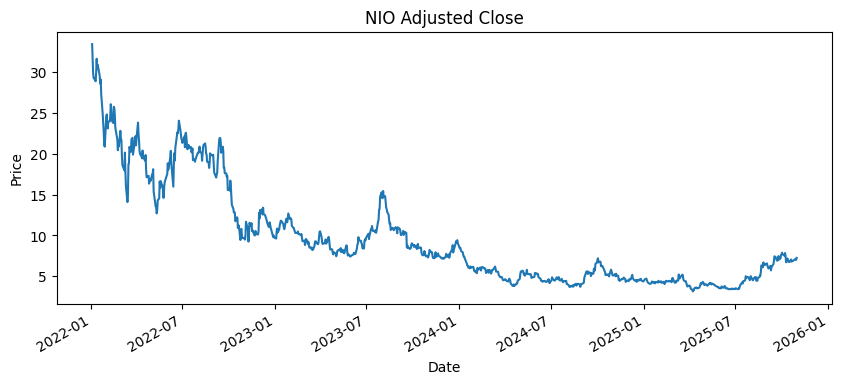


[Step 2] Train–test split...
Train: 2022-01-03 00:00:00 → 2025-05-12 00:00:00 | n= 842
Test : 2025-05-13 00:00:00 → 2025-10-31 00:00:00 | n= 120

[Step 3] Baseline models...
           RMSE       MAE  sMAPE (%)  DirAcc (%)
Naive  1.825926  1.431750  27.612956    1.680672
MA(5)  0.332928  0.234017   4.386179   44.537815


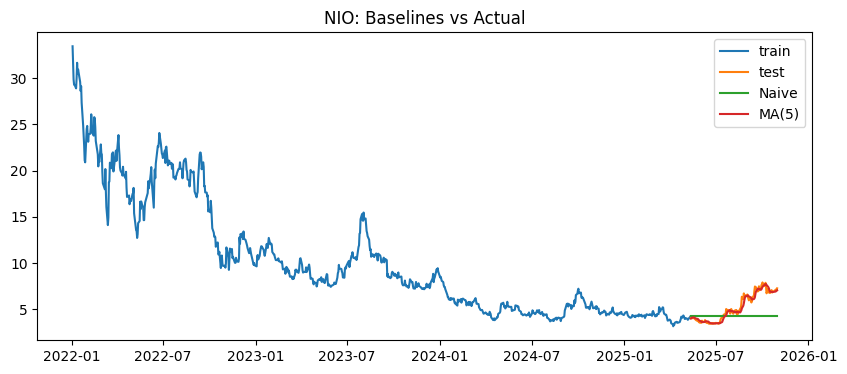


[Step 4] ARIMA (walk-forward) on log price...
RMSE           0.236903
MAE            0.171518
sMAPE (%)      3.139184
DirAcc (%)    43.697479
Name: SARIMAX(1, 1, 0), dtype: float64


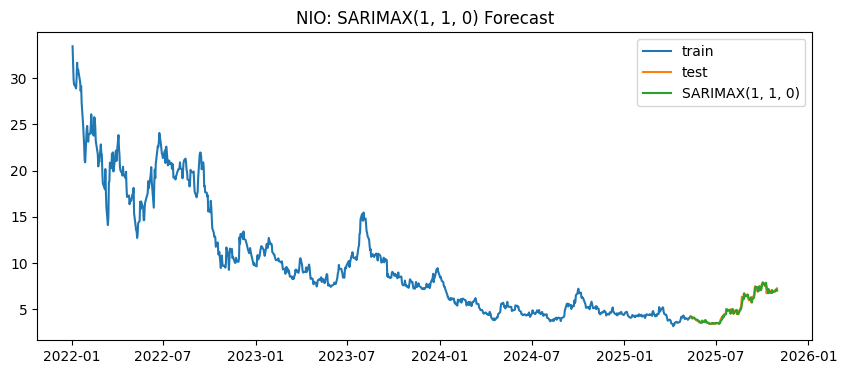


[Step 5] LSTM (windowed next-day price)...
RMSE           0.266630
MAE            0.204585
sMAPE (%)      3.978065
DirAcc (%)    45.378151
Name: LSTM, dtype: float64


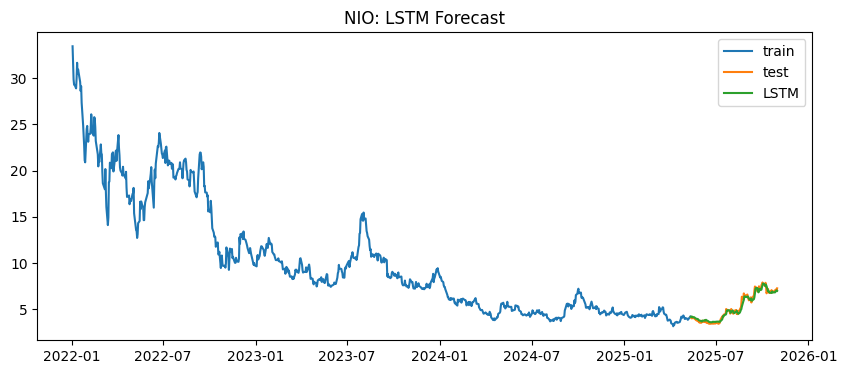


[Step 5b] Improved LSTM (windowed next-day price)...
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/stepWARNING:tensorflow:6 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001A72840D760> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
RMSE           0.907067
MAE            0.589946
sMAPE (%)     15.408640
DirAcc (%)    55.932203
Name: Improved LSTM, dtype: float64


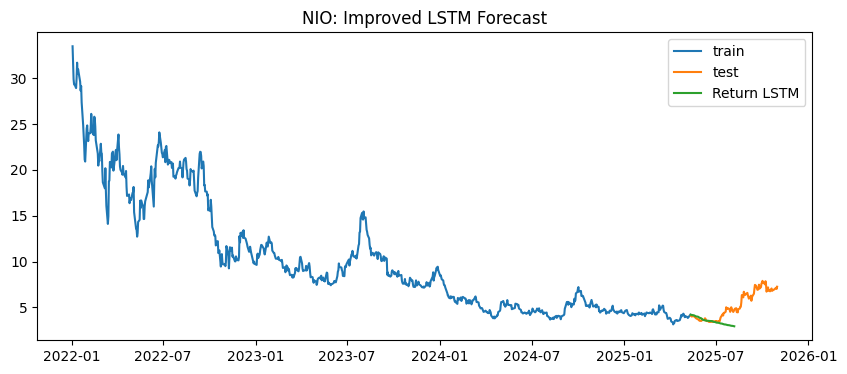


[Step 6] Comparison summary:
                      RMSE       MAE  sMAPE (%)  DirAcc (%)
SARIMAX(1, 1, 0)  0.236903  0.171518   3.139184   43.697479
LSTM              0.266630  0.204585   3.978065   45.378151
MA(5)             0.332928  0.234017   4.386179   44.537815
Naive             1.825926  1.431750  27.612956    1.680672


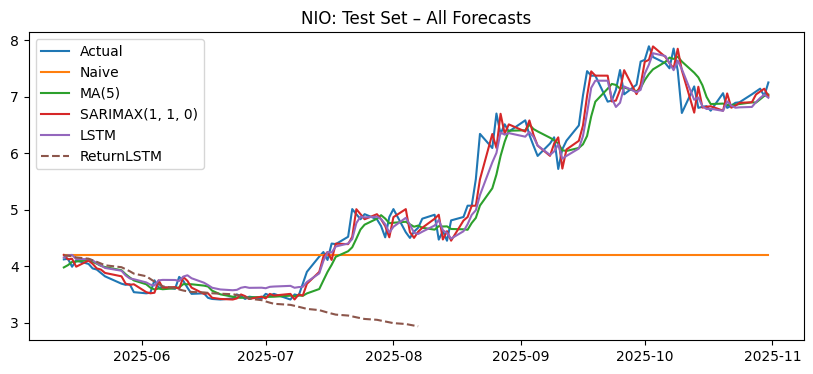

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import sys
import math
from math import sqrt
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import yfinance as yf

import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Try pmdarima for auto_arima; fall back to manual SARIMAX grid if unavailable
HAVE_PM = True
try:
    import pmdarima as pm
except Exception as e:
    HAVE_PM = False
    print("pmdarima not available; falling back to a small manual SARIMAX grid. Reason:", e)

# Try TensorFlow (tf.keras)
try:
    import tensorflow as tf
    from tensorflow import keras
except Exception as e:
    raise RuntimeError("TensorFlow not available. Install tensorflow (or tensorflow-macos on Apple Silicon).") from e


# ---------------------------
# Utility metrics & helpers
# ---------------------------

def rmse(y_true, y_pred):
    return sqrt(mean_squared_error(y_true, y_pred))

def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    mask = denom != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100

def directional_accuracy(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    if len(y_true) < 2 or len(y_pred) < 2:
        return np.nan
    true_dir = np.sign(np.diff(y_true))
    pred_dir = np.sign(np.diff(y_pred))
    m = min(len(true_dir), len(pred_dir))
    return np.mean(true_dir[:m] == pred_dir[:m]) * 100

def eval_series(y_true, y_pred):
    # Align indexes to be safe (for pandas Series)
    if isinstance(y_true, (pd.Series, pd.DataFrame)) and isinstance(y_pred, (pd.Series, pd.DataFrame)):
        y_true, y_pred = y_true.squeeze().align(pd.Series(y_pred).squeeze(), join='inner')
    else:
        y_true, y_pred = np.array(y_true), np.array(y_pred)
    return {
        "RMSE": rmse(y_true, y_pred),
        "MAE" : mean_absolute_error(y_true, y_pred),
        "sMAPE (%)": smape(y_true, y_pred),
        "DirAcc (%)": directional_accuracy(y_true, y_pred)
    }

# ---------------------------
# Data loading
# ---------------------------

# DROP-IN REPLACEMENT for your load_prices() to fix "['Adj Close'] not in index" errors
# Handles: MultiIndex columns (yfinance), missing 'Adj Close' (falls back to 'Close'),
# auto-adjusted downloads, and ensures a single 'close' column with a DatetimeIndex.

import pandas as pd
import yfinance as yf

# --- REPLACE your existing load_prices() with this more robust version ---

import pandas as pd
import yfinance as yf

def load_prices(ticker: str, start: str = "2015-01-01", end: str | None = None) -> pd.DataFrame:
    """
    Robustly fetch daily prices from Yahoo Finance and return a DataFrame with one column:
      - 'close' = adjusted close if available, else close
    Handles: MultiIndex columns, single-column frames like ['TSLA'], auto-adjust cases.
    """
    def _pick_close(df: pd.DataFrame) -> pd.Series:
        # If MultiIndex (typical: top=ticker, bottom=OHLCV)
        if isinstance(df.columns, pd.MultiIndex):
            top = [str(x).upper() for x in df.columns.get_level_values(0)]
            bot = [str(x).lower() for x in df.columns.get_level_values(1)]
            # try to match the requested ticker block if present
            if ticker.upper() in top:
                block = df.xs(ticker.upper(), axis=1, level=0, drop_level=False)
            else:
                # fallback to first block
                first = df.columns.get_level_values(0).unique()[0]
                block = df.xs(first, axis=1, level=0, drop_level=False)
            # now pick column within the block
            cols_lower = {c.lower(): c for c in block.columns.get_level_values(-1)}
            if 'adj close' in cols_lower:
                return block.xs(cols_lower['adj close'], axis=1, level=-1, drop_level=False).iloc[:, 0]
            if 'close' in cols_lower:
                return block.xs(cols_lower['close'], axis=1, level=-1, drop_level=False).iloc[:, 0]
            # last resort: if block has exactly one column, use it
            if block.shape[1] == 1:
                return block.iloc[:, 0]
            raise ValueError(f"No Close/Adj Close under MultiIndex. Bottom-level columns: {sorted(set(bot))}")

        # Single-level columns
        cols_lower = {str(c).lower(): c for c in df.columns}
        if 'adj close' in cols_lower:
            return df[cols_lower['adj close']]
        if 'close' in cols_lower:
            return df[cols_lower['close']]
        # Some downloads return a single unnamed ticker column like ['TSLA']
        if df.shape[1] == 1:
            return df.iloc[:, 0]
        raise ValueError(f"No 'Adj Close' or 'Close' in columns: {list(df.columns)}")

    # Try standard (keeps both Close and Adj Close)
    df = yf.download(
        tickers=ticker,
        start=start,
        end=end,
        auto_adjust=False,
        group_by='column',
        progress=False
    )
    if df is None or df.empty:
        raise ValueError(f"No data returned for {ticker}. Check ticker/date range.")

    try:
        s = _pick_close(df)
    except Exception:
        # Retry with auto_adjust=True (yfinance then drops Adj Close and uses Close adjusted)
        df2 = yf.download(
            tickers=ticker,
            start=start,
            end=end,
            auto_adjust=True,
            group_by='column',
            progress=False
        )
        if df2 is None or df2.empty:
            raise ValueError(f"No data returned for {ticker} on retry with auto_adjust=True.")
        s = _pick_close(df2)

    s = s.rename('close').dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    s = s.sort_index()
    return s.to_frame()


# ---------------------------
# Baselines
# ---------------------------

def baseline_predictions(train: pd.Series, test: pd.Series, k: int = 5):
    """
    Naive: last train value for all test dates
    MA(k): moving average up to t-1 (no lookahead)
    """
    naive_pred = pd.Series(train.iloc[-1], index=test.index, name='Naive')
    roll_all = pd.concat([train, test]).rolling(k).mean()
    ma_pred = roll_all.shift(1).reindex(test.index)
    ma_pred.name = f"MA({k})"
    return naive_pred, ma_pred

# ---------------------------
# ARIMA (walk-forward) on log-price
# ---------------------------

def walk_forward_arima(train_log: pd.Series, test_log: pd.Series) -> tuple[pd.Series, str]:
    """
    Fit ARIMA order by auto_arima (if available), otherwise pick best from a tiny grid by AIC.
    Walk-forward: refit or update at each step to forecast one day ahead.
    Returns predictions in log space, aligned to test index, and the model label string.
    """
    preds = []
    history = train_log.copy()

    if HAVE_PM:
        # initial ARIMA order via auto_arima
        auto_model = pm.auto_arima(
            history,
            seasonal=False, d=None, start_p=0, start_q=0, max_p=5, max_q=5,
            stepwise=True, suppress_warnings=True, error_action='ignore'
        )
        order = auto_model.order
        label = f"ARIMA{order}"

        # one-step-ahead walk-forward
        for _t in test_log:
            model = pm.ARIMA(order=order)
            model.fit(history.values)
            preds.append(model.predict(n_periods=1)[0])
            # append actual obs to history (index increment is not important for the model)
            history = pd.concat([history, pd.Series([_t], index=[history.index[-1] + pd.Timedelta(days=1)])])

    else:
        # tiny manual grid if pmdarima not available
        candidate_orders = [(1,1,0), (0,1,1), (1,1,1), (2,1,1)]
        best_aic, best_order = float("inf"), None
        for o in candidate_orders:
            try:
                res = SARIMAX(history, order=o, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                if res.aic < best_aic:
                    best_aic, best_order = res.aic, o
            except Exception:
                pass
        if best_order is None:
            best_order = (1,1,0)
        label = f"SARIMAX{best_order}"

        for _t in test_log:
            res = SARIMAX(history, order=best_order, enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            preds.append(res.forecast(1).iloc[0])
            history = pd.concat([history, pd.Series([_t], index=[history.index[-1] + pd.Timedelta(days=1)])])

    pred_log_series = pd.Series(preds, index=test_log.index, name=label)
    return pred_log_series, label

# ---------------------------
# LSTM (next-day price, windowed)
# ---------------------------

def make_windows(values: np.ndarray, index: pd.Index, window: int):
    """
    Build sliding windows on a 1D array of values.
    Returns X, y, and y_times (timestamps for each target y).
    X shape = (n_samples, window, 1)
    """
    X, y, times = [], [], []
    for i in range(len(values) - window):
        X.append(values[i:i+window])
        y.append(values[i+window])
        times.append(index[i+window])
    X = np.array(X)
    y = np.array(y)
    return X, y, pd.Index(times)

def lstm_forecast(train: pd.Series, test: pd.Series, window: int = 60, seed: int = 42) -> pd.Series:
    """
    Train an LSTM on scaled train+test (scaler fit on train only) using sliding windows.
    Predict on windows whose target timestamps fall in the test segment.
    Returns a prediction series aligned to test.index.
    """
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train.values.reshape(-1,1))
    test_scaled  = scaler.transform(test.values.reshape(-1,1))
    all_scaled = np.vstack([train_scaled, test_scaled]).astype('float32')
    all_index = pd.Index(train.index.tolist() + test.index.tolist())

    X_all, y_all, y_times = make_windows(all_scaled.flatten(), all_index, window)

    # split windows by target timestamp
    last_train_time = train.index[-1]
    train_mask = y_times <= last_train_time
    test_mask  = y_times >  last_train_time

    X_tr = X_all[train_mask].reshape((-1, window, 1))
    y_tr = y_all[train_mask].reshape((-1, 1))

    X_te = X_all[test_mask].reshape((-1, window, 1))
    y_te_times = y_times[test_mask]  # these should align with trading days in test

    if X_te.shape[0] == 0:
        raise ValueError("Window too large for the chosen split; decrease W or provide more data.")

    # Build the model
    tf.random.set_seed(seed)
    model = keras.Sequential([
        keras.layers.Input(shape=(window, 1)),
        keras.layers.LSTM(64, return_sequences=True),
        keras.layers.LSTM(32),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')

    # Validation split from the training windows
    n_val = max(1, int(len(X_tr) * 0.2))
    X_train, X_val = X_tr[:-n_val], X_tr[-n_val:]
    y_train, y_val = y_tr[:-n_val], y_tr[-n_val:]

    es = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=200, batch_size=32, callbacks=[es], verbose=0)

    # Predict (scaled), then invert scale to price
    yhat_scaled = model.predict(X_te, verbose=0).flatten().reshape(-1,1)
    yhat = scaler.inverse_transform(yhat_scaled).flatten()

    # Align to test index (some early windows may target the first test day)
    pred = pd.Series(yhat, index=y_te_times, name='LSTM').reindex(test.index)
    return pred


def lstm_return_forecast(train, test, window=10, seed=42):
    df = pd.concat([train, test]).to_frame("close")
    df["log_price"] = np.log(df["close"])
    df["returns"] = df["log_price"].diff().dropna()
    df = df.dropna()

    train_r = df["returns"].loc[train.index.min():train.index.max()]
    test_r  = df["returns"].loc[test.index.min():test.index.max()]

    scaler = MinMaxScaler(feature_range=(-1,1))
    train_s = scaler.fit_transform(train_r.values.reshape(-1,1))
    test_s  = scaler.transform(test_r.values.reshape(-1,1))

    def make_seq(data, window):
        X,y=[],[]
        for i in range(window,len(data)):
            X.append(data[i-window:i,0]); y.append(data[i,0])
        return np.array(X), np.array(y)
    X_tr,y_tr=make_seq(train_s,window)
    X_te,y_te=make_seq(test_s,window)
    X_tr=X_tr.reshape((X_tr.shape[0],window,1)); X_te=X_te.reshape((X_te.shape[0],window,1))

    tf.random.set_seed(seed)
    model=keras.Sequential([
        keras.layers.LSTM(64, return_sequences=True, input_shape=(window,1)),
        keras.layers.Dropout(0.2),
        keras.layers.LSTM(32),
        keras.layers.Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    model.fit(X_tr,y_tr,epochs=40,batch_size=16,verbose=0)

    y_pred_s=model.predict(X_te)
    y_pred=scaler.inverse_transform(y_pred_s)

    start_price=train.iloc[-1]
    pred_log=np.log(start_price)+np.cumsum(y_pred.flatten())
    pred_price=np.exp(pred_log)
    pred_series=pd.Series(pred_price,index=test.index[:len(pred_price)],name='ReturnLSTM')
    return pred_series


print("\n=== ARIMA vs LSTM on Stock Prices ===")
ticker = input("Enter a Yahoo Finance ticker (default AAPL): ").strip().upper() or "AAPL"
start  = input("Start date YYYY-MM-DD (default 2015-01-01): ").strip() or "2015-01-01"
end    = input("End date YYYY-MM-DD or leave blank for today: ").strip() or None

try:
    TEST_DAYS = int(input("Test set size in days (default 120): ").strip() or "120")
except ValueError:
    TEST_DAYS = 120

try:
    W = int(input("LSTM window size in days (default 60): ").strip() or "60")
except ValueError:
    W = 60

print("\n[Step 1] Downloading data...")
ts = load_prices(ticker, start, end)
print(ts.head(), "\n...\n", ts.tail())
print("Shape:", ts.shape)

plt.figure(figsize=(10,4))
ts['close'].plot(title=f"{ticker} Adjusted Close", ylabel="Price")
plt.show()

# Split
if len(ts) <= TEST_DAYS + W + 5:
    raise ValueError("Not enough data for the requested TEST_DAYS and window W. Choose earlier start, smaller TEST_DAYS, or smaller W.")

print("\n[Step 2] Train–test split...")
train = ts['close'].iloc[:-TEST_DAYS].copy()
test  = ts['close'].iloc[-TEST_DAYS:].copy()
print("Train:", train.index.min(), "→", train.index.max(), "| n=", len(train))
print("Test :", test.index.min(),  "→", test.index.max(),  "| n=", len(test))

# Baselines
print("\n[Step 3] Baseline models...")
naive_pred, ma_pred = baseline_predictions(train, test, k=5)
baseline_scores = {
    "Naive": eval_series(test, naive_pred),
    "MA(5)": eval_series(test, ma_pred)
}
print(pd.DataFrame(baseline_scores).T)

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(test.index, naive_pred, label='Naive')
plt.plot(test.index, ma_pred, label='MA(5)')
plt.title(f"{ticker}: Baselines vs Actual")
plt.legend()
plt.show()

# ARIMA
print("\n[Step 4] ARIMA (walk-forward) on log price...")
train_log = np.log(train)
test_log  = np.log(test)
arima_log_pred, arima_label = walk_forward_arima(train_log, test_log)
arima_pred = pd.Series(np.exp(arima_log_pred.values), index=test.index, name=arima_label)
arima_scores = eval_series(test, arima_pred)
print(pd.Series(arima_scores, name=arima_label))

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(arima_pred.index, arima_pred.values, label=arima_label)
plt.title(f"{ticker}: {arima_label} Forecast")
plt.legend()
plt.show()

# LSTM
print("\n[Step 5] LSTM (windowed next-day price)...")
lstm_pred = lstm_forecast(train, test, window=W, seed=42)
lstm_scores = eval_series(test, lstm_pred)
print(pd.Series(lstm_scores, name='LSTM'))

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(lstm_pred.index, lstm_pred.values, label='LSTM')
plt.title(f"{ticker}: LSTM Forecast")
plt.legend()
plt.show()

# LSTM
print("\n[Step 5b] Improved LSTM (windowed next-day price)...")
return_pred = lstm_return_forecast(train, test, window=W, seed=42)
return_scores = eval_series(test, return_pred)
print(pd.Series(return_scores, name='Improved LSTM'))

plt.figure(figsize=(10,4))
plt.plot(train.index, train, label='train')
plt.plot(test.index, test, label='test')
plt.plot(return_pred.index, return_pred.values, label='Return LSTM')
plt.title(f"{ticker}: Improved LSTM Forecast")
plt.legend()
plt.show()

# Summary table
print("\n[Step 6] Comparison summary:")
summary = pd.DataFrame({
    "Naive": baseline_scores["Naive"],
    "MA(5)": baseline_scores["MA(5)"],
    arima_label: arima_scores,
    "LSTM": lstm_scores
}).T[["RMSE","MAE","sMAPE (%)","DirAcc (%)"]].sort_values("RMSE")
print(summary)

plt.figure(figsize=(10,4))
plt.plot(test.index, test, label='Actual')
plt.plot(naive_pred.index, naive_pred, label='Naive')
plt.plot(ma_pred.index, ma_pred, label='MA(5)')
plt.plot(arima_pred.index, arima_pred.values, label=arima_label)
plt.plot(lstm_pred.index, lstm_pred.values, label='LSTM')
plt.plot(return_pred.index, return_pred, label='ReturnLSTM', linestyle='--')
plt.title(f"{ticker}: Test Set – All Forecasts")
plt.legend()
plt.show()

**Interpretation**

- Changed to return based lstm which changes the input representation to log returns. 
- SARIMAX had the lowest RMSE, meaning it matched the actual price levels most closely, and it also had the best sMAPE.
- LSTM slightly outperformed in Directional Accuracy which suggests that it predicted the up/down trend correctly a bit more often.
- All models track the general rise in prices from mid-2025 onward, but SARIMAX and LSTM slightly lag when sharp rebounds occur.
- ARIMA’s log-differencing stabilized variance and removed trend bias.
- Even with the change, the model didn't correctly integrate back to cumulative price. 